# 유니버스 golden_cross 분석

`list_universe` → `run_universe_backtest` → 종목·기간 공통점.

**효과:** `excess_return > 0` 그리고 `max_drawdown >= mdd_limit` (기본 -30%).

**생존편향:** 기준일 시총으로 고른 뒤 과거부터 돌리면, 그 날짜에 남아 있는 대형주만 남습니다. PIT에 가깝게 보려면 `as_of`를 백테스트 `start`로 맞추세요. `as_of`가 휴일이면 그 이전 마지막 거래일을 씁니다.

업종은 `security_master`에 없습니다. 공통점은 시장·시총·실현변동성·buy&hold(추세)·거래횟수로 봅니다.

전체 유니버스(~1,200종목)는 수분 걸릴 수 있습니다. `MAX_NAMES`로 스모크하거나, 저장된 parquet를 로드하세요.

투자 조언을 제공하지 않습니다.

In [1]:
from datetime import date
from pathlib import Path

from backtest import list_universe, load_run_panel, run_universe_backtest, save_run_panel
from backtest.analytics import (
    attach_size_quintile,
    period_hit_rates,
    plot_excess_scatter,
    plot_period_hit_rate,
    stock_axis_summary,
    stock_group_summary,
)

as_of = date(2015, 1, 2)
min_market_cap = 100_000_000_000  # 1,000억 원
start = date(2015, 1, 2)
end = None
fast = 50
slow = 200
initial_cash = 10_000_000.0
fee_rate = 0.0015
mdd_limit = -0.30
MAX_NAMES = 40  # 전체는 None
RUN_DIR = Path("backtest_runs") / f"golden_cross_cap1000eok_{as_of.isoformat()}"
RELOAD = RUN_DIR.exists() and MAX_NAMES is None

In [2]:
universe = list_universe(
    as_of=as_of,
    min_market_cap=min_market_cap,
)
print(f"universe n={len(universe)}")
if universe.empty:
    print("empty universe — as_of 이전에 일봉이 없습니다")
else:
    print(f"session as_of={universe['as_of'].dt.date.iloc[0]}")
universe.head()

universe n=732
session as_of=2015-01-02


,security_id,name,market,market_cap,as_of
0,KRX:005930,삼성전자,KOSPI,1.959081e+14,2015-01-02
1,KRX:005380,현대차,KOSPI,3.722672e+13,2015-01-02
2,KRX:000660,SK하이닉스,KOSPI,3.476211e+13,2015-01-02
3,KRX:015760,한국전력,KOSPI,2.741187e+13,2015-01-02
4,KRX:005490,POSCO홀딩스,KOSPI,2.471747e+13,2015-01-02


In [3]:
if RELOAD:
    panel = load_run_panel(RUN_DIR)
    print(f"loaded {RUN_DIR}")
else:
    names = universe if MAX_NAMES is None else universe.head(MAX_NAMES)
    panel = run_universe_backtest(
        "golden_cross",
        names,
        start=start,
        end=end,
        initial_cash=initial_cash,
        fee_rate=fee_rate,
        mdd_limit=mdd_limit,
        fast=fast,
        slow=slow,
    )
    if MAX_NAMES is None:
        save_run_panel(panel, RUN_DIR)
        print(f"saved {RUN_DIR}")

summaries = attach_size_quintile(panel.summaries)
ok = summaries[summaries["error"].fillna("") == ""]
print(f"ok={len(ok)}  effective={int(ok['effective'].sum())}  errors={int((summaries['error'].fillna('') != '').sum())}")
ok.sort_values("excess_return", ascending=False).head(10)

ok=40  effective=0  errors=0


,security_id,name,market,market_cap,total_return,buy_hold_return,excess_return,max_drawdown,buy_hold_mdd,cagr,realized_vol,trade_count,bars,effective,error,size_quintile
8,KRX:005935,삼성전자우,KOSPI,2.319876e+13,7.102257,-0.851378,7.953635,-0.357447,-0.986959,0.204147,0.076743,15,2838,False,,Q4
38,KRX:161390,한국타이어앤테크놀로지,KOSPI,6.391954e+12,1.809101,0.261628,1.547473,-0.390565,-0.766117,0.095944,0.023574,13,2841,False,,Q1
6,KRX:035420,NAVER,KOSPI,2.409572e+13,0.687465,-0.733653,1.421118,-0.521208,-0.889062,0.047556,0.037885,14,2838,False,,Q5
4,KRX:005490,POSCO홀딩스,KOSPI,2.471747e+13,1.393178,0.059965,1.333213,-0.460748,-0.650633,0.080477,0.023486,9,2841,False,,Q5
30,KRX:006400,삼성SDI,KOSPI,8.045450e+12,3.127802,2.064103,1.063700,-0.496489,-0.803917,0.134005,0.027860,17,2841,False,,Q2
35,KRX:088350,한화생명,KOSPI,6.904814e+12,0.429159,-0.471069,0.900228,-0.478317,-0.895322,0.032181,0.025467,13,2841,False,,Q1
39,KRX:001800,오리온홀딩스,KOSPI,5.974969e+12,-0.078314,-0.974650,0.896336,-0.438430,-0.992213,-0.007276,0.063407,19,2814,False,,Q1
17,KRX:051910,LG화학,KOSPI,1.192880e+13,1.055145,0.363889,0.691256,-0.622519,-0.822568,0.065981,0.027027,10,2841,False,,Q3
27,KRX:023530,롯데쇼핑,KOSPI,8.376577e+12,-0.082365,-0.576692,0.494327,-0.556200,-0.837072,-0.007638,0.023282,19,2825,False,,Q2
5,KRX:018260,삼성에스디에스,KOSPI,2.460614e+13,0.063940,-0.375157,0.439097,-0.486740,-0.672836,0.005513,0.024351,13,2841,False,,Q5


## 종목: 효과적 vs 비효과적

그룹 중앙값과 시장·시총 분위 분포. 상위/하위 excess 종목을 비교하세요.

In [4]:
display(stock_group_summary(summaries))
display(stock_axis_summary(summaries, by="market"))
display(stock_axis_summary(summaries, by="size_quintile"))
print("least excess")
display(ok.sort_values("excess_return").head(10))

,effective,n,excess_median,mdd_median,market_cap_median,trade_count_median,realized_vol_median,buy_hold_median
0,False,40,-0.027266,-0.522969,1.153228e+13,16.0,0.023771,0.440398


,market,effective,n,excess_median
0,KOSPI,False,40,-0.027266


/Users/jaeyulim/my-project/trading-workspace/trading-labs/src/backtest/analytics/cross_section.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frame.groupby([by, "effective"], dropna=False)


,size_quintile,effective,n,excess_median
0,Q1,False,8,0.352860
1,Q2,False,8,-0.003989
2,Q3,False,8,-0.309912
3,Q4,False,8,-0.123606
4,Q5,False,8,-0.060917


least excess


,security_id,name,market,market_cap,total_return,buy_hold_return,excess_return,max_drawdown,buy_hold_mdd,cagr,realized_vol,trade_count,bars,effective,error,size_quintile
2,KRX:000660,SK하이닉스,KOSPI,3.476211e+13,24.285900,26.685864,-2.399964,-0.547105,-0.547105,0.331794,0.027700,13,2841,False,,Q5
14,KRX:105560,KB금융,KOSPI,1.390866e+13,1.695022,3.650000,-1.954978,-0.486391,-0.620262,0.091921,0.020441,11,2841,False,,Q4
21,KRX:033780,KT&G,KOSPI,1.073627e+13,-0.183781,1.375959,-1.559741,-0.525380,-0.535766,-0.017852,0.015298,25,2841,False,,Q3
1,KRX:005380,현대차,KOSPI,3.722672e+13,-0.066399,1.076923,-1.143322,-0.532000,-0.641848,-0.006076,0.022818,19,2841,False,,Q5
0,KRX:005930,삼성전자,KOSPI,1.959081e+14,5.751280,6.781955,-1.030675,-0.428966,-0.451648,0.184801,0.020244,13,2838,False,,Q5
25,KRX:086790,하나금융지주,KOSPI,9.276610e+12,1.912505,2.893750,-0.981245,-0.405646,-0.667568,0.099464,0.021277,15,2841,False,,Q2
32,KRX:010130,고려아연,KOSPI,7.651785e+12,0.390000,1.281134,-0.891134,-0.673500,-0.673500,0.029640,0.027771,16,2841,False,,Q1
20,KRX:034730,SK,KOSPI,1.152500e+13,0.145705,1.032538,-0.886833,-0.721352,-0.674930,0.012138,0.024835,15,2841,False,,Q3
13,KRX:055550,신한지주,KOSPI,2.110188e+13,0.408556,1.265169,-0.856613,-0.534102,-0.599278,0.030852,0.018396,21,2841,False,,Q4
22,KRX:003550,LG,KOSPI,1.068129e+13,-0.088343,0.557351,-0.645693,-0.474362,-0.537549,-0.008222,0.021658,15,2823,False,,Q3


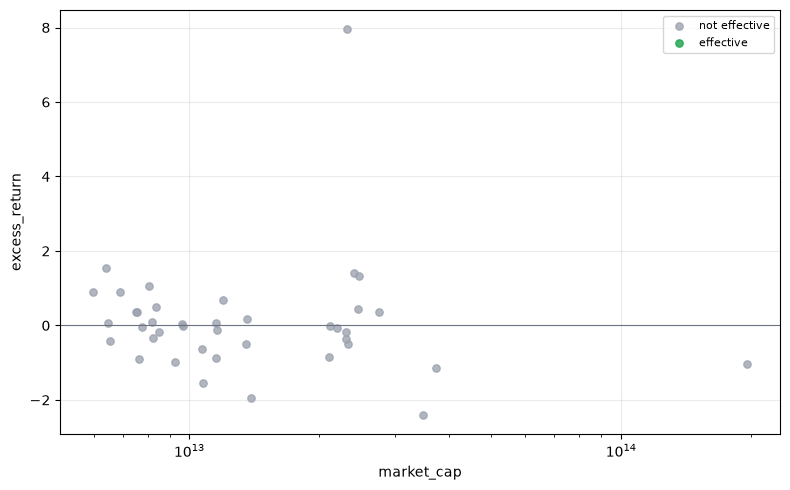

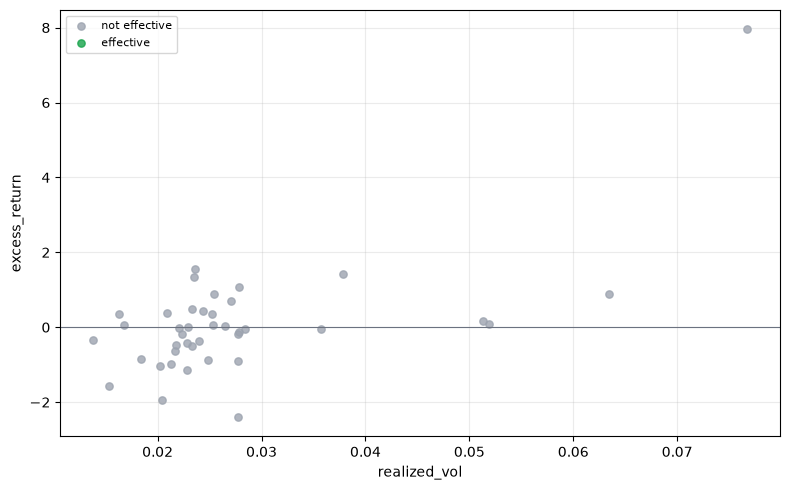

In [5]:
plot_excess_scatter(summaries, x="market_cap", show=True)
plot_excess_scatter(summaries, x="realized_vol", show=True)

## 기간: 언제 효과가 있었나

연도별 hit rate(`excess>0` 비율)와 그해 유니버스 buy&hold 중앙값. 장세가 강한 해와 hit rate가 같이 움직이는지 봅니다.

,period,freq,n,hit_rate,excess_median,universe_bh_median
0,2015,YE,40,0.625,0.057453,-0.082100
1,2016,YE,40,0.325,-0.035064,0.026638
2,2017,YE,40,0.275,-0.064696,0.114329
3,2018,YE,40,0.675,0.115157,-0.202869
4,2019,YE,40,0.400,-0.054885,0.027169
5,2020,YE,40,0.425,-0.047862,0.048913
6,2021,YE,40,0.600,0.018826,0.000320
7,2022,YE,40,0.600,0.076577,-0.147147
8,2023,YE,40,0.200,-0.111667,0.097742
9,2024,YE,40,0.475,0.000000,-0.109610


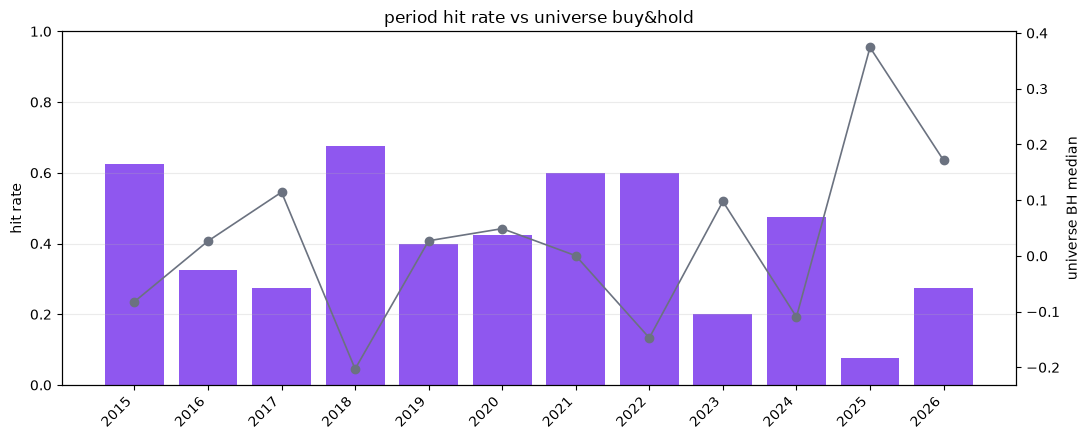

In [6]:
yearly = period_hit_rates(panel.period_returns, freq="YE")
display(yearly)
plot_period_hit_rate(yearly, show=True)

In [7]:
monthly = period_hit_rates(panel.period_returns, freq="ME")
monthly.tail(24)

,period,freq,n,hit_rate,excess_median,universe_bh_median
115,2024-08,ME,40,0.325,0.000000e+00,-0.025487
116,2024-09,ME,40,0.400,0.000000e+00,0.013221
117,2024-10,ME,40,0.525,2.220446e-16,0.003584
118,2024-11,ME,40,0.450,0.000000e+00,-0.013480
119,2024-12,ME,40,0.525,1.110223e-16,-0.047678
120,2025-01,ME,40,0.275,-1.110223e-16,0.039698
121,2025-02,ME,40,0.350,0.000000e+00,0.002752
122,2025-03,ME,40,0.425,0.000000e+00,-0.012219
123,2025-04,ME,40,0.300,-2.220446e-16,0.025995
124,2025-05,ME,40,0.275,0.000000e+00,0.034578
